In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("Kmeans.csv")
df.head()


,Customer_ID,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer_ID     30 non-null     int64
 1   Age             30 non-null     int64
 2   Annual_Income   30 non-null     int64
 3   Spending_Score  30 non-null     int64
dtypes: int64(4)
memory usage: 1.1 KB


In [4]:
df.describe()


,Customer_ID,Age,Annual_Income,Spending_Score
count,30.000000,30.000000,30.000000,30.000000
mean,15.500000,35.233333,21.966667,49.700000
std,8.803408,14.383140,5.013660,32.729982
min,1.000000,19.000000,15.000000,3.000000
25%,8.250000,23.000000,18.250000,15.000000
50%,15.500000,33.000000,20.000000,50.500000
75%,22.750000,43.750000,27.250000,77.000000
max,30.000000,67.000000,30.000000,99.000000


In [5]:
X = df.drop("Customer_ID", axis=1)
X.head()


,Age,Annual_Income,Spending_Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

wcss


[90.0,
 48.22912205573941,
 34.08434347166801,
 21.25732768100874,
 14.0373473885215,
 12.27794597039074,
 10.104315680927769,
 9.589406028399111,
 8.831642217583614,
 7.342170780307228]

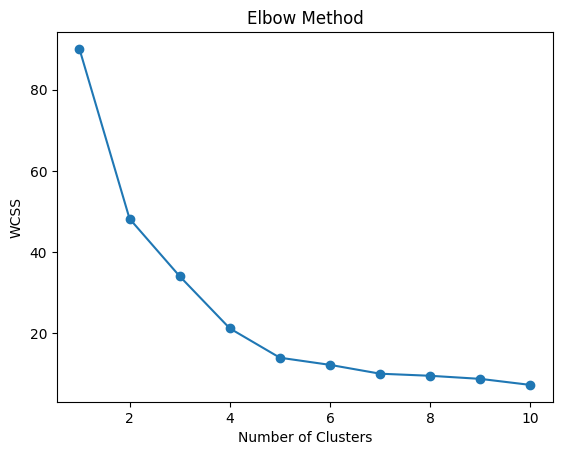

In [8]:
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()


,Customer_ID,Age,Annual_Income,Spending_Score,Cluster
0,1,19,15,39,2
1,2,21,15,81,0
2,3,20,16,6,2
3,4,23,16,77,0
4,5,31,17,40,2


In [10]:
df["Cluster"].value_counts()


Cluster
0    9
1    9
2    6
3    6
Name: count, dtype: int64

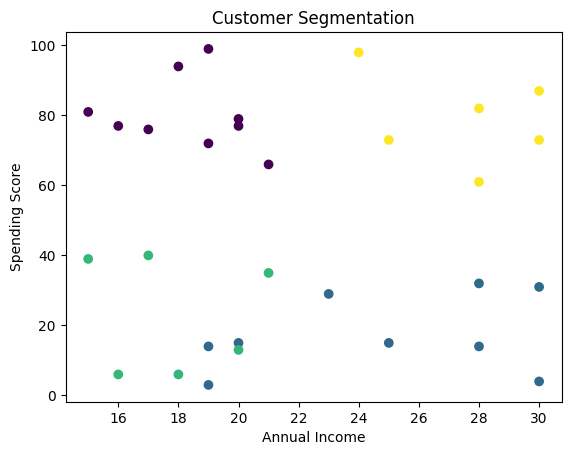

In [11]:
plt.figure()
plt.scatter(df["Annual_Income"], df["Spending_Score"], c=df["Cluster"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()


In [12]:
kmeans.cluster_centers_


array([[-0.76292992, -0.7370756 ,  0.94503556],
       [ 1.32707377,  0.54773508, -1.00235229],
       [-0.40542929, -0.83850802, -0.8245323 ],
       [-0.44078649,  1.12251881,  0.9105074 ]])